# OASIS-2 preprocessing

Brings raw OASIS-2 scans into the same image domain as the preprocessed OASIS-1 set,
so both can be used with the same `extract_slices()` function and the same CNN.

OASIS-2 is only available as RAW: skull, face, neck, tilted heads, and a
**different axis order**.

| | shape | zooms | axcodes |
|---|---|---|---|
| OASIS-1 | (176, 208, 176) | (1.0, 1.0, 1.0) | `('L','A','S')` |
| OASIS-2 RAW | (256, 256, 128, 1) | (1.0, 1.0, 1.25) | `('A','S','L')` |

`extract_slices()` uses `axis=2` with `slice_range=(80, 120)`. On OASIS-2 RAW that
would produce **sagittal** slices near the side of the skull, not axial ones through
the ventricles. It would not raise an error: it would silently generate 10 plausible
looking PNGs per patient and a completely invalid result.

## The pipeline

```
OASIS-1 volumes (already t88) --> average 30 --> TEMPLATE + brain mask
                                                       
OASIS-2 RAW mpr-1.nifti.hdr                            
                                              
   +-> reorient axes to ('L','A','S')                  
   +-> brain extraction (U-Net + convex hull)          
   +-> rigid registration to template
   +-> affine registration to template
   +-> apply template mask
   +-> extract_slices()  [unchanged]  --> PNG
```


---
## 1. Setup

In [ ]:
!pip install antspyx antspynet -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.6/147.6 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.6 MB/s eta 0:00:00


After this install, **Runtime -> Restart session** to avoid a scipy version
conflict (`ImportError: cannot import name '_lazywhere'`). Restarting the kernel
does not clear `/root/.cache`, so the downloads survive.

In [ ]:
import os, time, shutil
from pathlib import Path
import kagglehub
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import binary_closing, binary_dilation
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform
import ants

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
p1 = kagglehub.dataset_download("pbhanutejaswini/oasis-1-preprocessed-brain-mri")
p2 = kagglehub.dataset_download("javidtheimmortal/oasis-2")
print(p2)
print(p1)

100%|██████████| 1.07G/1.07G [00:58<00:00, 19.7MB/s]

Extracting files...


100%|██████████| 18.6G/18.6G [15:59<00:00, 20.8MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/javidtheimmortal/oasis-2/versions/1
/root/.cache/kagglehub/datasets/pbhanutejaswini/oasis-1-preprocessed-brain-mri/versions/1


In [ ]:
# Resolve dataset paths from the kagglehub cache; only download if missing.
CACHE = Path("/root/.cache/kagglehub/datasets")

def ruta_dataset(slug):
    """slug tipo 'usuario/nombre'. Devuelve la carpeta versions/N ya extraida."""
    base = CACHE / slug.replace("/", "/")
    vers = sorted((base / "versions").glob("*")) if (base / "versions").exists() else []
    if vers:
        print("cache:", slug)
        return str(vers[-1])
    print("descargando:", slug)
    return kagglehub.dataset_download(slug)

p1 = ruta_dataset("pbhanutejaswini/oasis-1-preprocessed-brain-mri")
p2 = ruta_dataset("javidtheimmortal/oasis-2")
print("p1:", p1)
print("p2:", p2)

descargando: pbhanutejaswini/oasis-1-preprocessed-brain-mri


KeyboardInterrupt: 

In [ ]:
WORK = Path("/content/drive/MyDrive/AlzheimersProject/oasis2")
SL   = WORK / "slices_external"
TPL  = WORK / "template.nii.gz"
MSK  = WORK / "brain_mask.nii.gz"
CSV  = Path("/content/drive/MyDrive/AlzheimersProject/oasis_2.csv")
WORK.mkdir(parents=True, exist_ok=True)

# Resolve the folders that actually contain the images, rather than hardcoding
# the nesting (both datasets have duplicated subfolders)
nii = sorted(Path(p1).rglob("*.nii"))
assert nii, "OASIS-1 vacio: relanza A2"
O1 = nii[0].parent

O2   = Path(p2)
hdrs = sorted(O2.rglob("*.hdr"))
assert hdrs, "OASIS-2 vacio: relanza A2"

sesiones = {p.parent.parent.name for p in hdrs}
print("O1  :", O1, "|", len(nii), ".nii")
print("O2  :", O2)
print("hdr :", len(hdrs), "| sesiones:", len(sesiones))
print("PART:", sorted({p.name for p in O2.rglob("OAS2_RAW_PART*")}))
print("CSV :", CSV.exists(), "| TPL:", TPL.exists(), "| MSK:", MSK.exists())

NameError: name 'p1' is not defined

In [ ]:
O2 = Path(p2)
hdrs = sorted(O2.rglob("*.hdr"))
imgs = sorted(O2.rglob("*.img"))
print("hdr:", len(hdrs), "| img:", len(imgs))
print("sesiones:", len({p.parent.parent.name for p in hdrs}))
print("PART:", sorted({p.name for p in O2.rglob("OAS2_RAW_PART*")}))

# un .img completo de 256x256x128 en 16 bits pesa ~16 MB
tam = [os.path.getsize(p) for p in imgs]
print("tamaño .img: min", min(tam)//1024//1024, "MB | max", max(tam)//1024//1024, "MB")
print("sospechosos (<8MB):", sum(1 for t in tam if t < 8*1024*1024))

hdr: 1346 | img: 1346
sesiones: 367
PART: ['OAS2_RAW_PART1', 'OAS2_RAW_PART2']
tamaño .img: min 24 MB | max 32 MB
sospechosos (<8MB): 0


---
# 2. Template

The OASIS-1 volumes are **already in t88 space**, so they are aligned with each other. The template is a plain voxel-wise average, no registration required.

Built once and cached on Drive; later sessions load it in a second.

In [ ]:
if TPL.exists():
    t_img           = nib.load(TPL)
    template_data   = t_img.get_fdata()
    template_affine = t_img.affine
    mask            = nib.load(MSK).get_fdata().astype(bool)
    print("cargado desde Drive")

else:
    files  = sorted(O1.glob("*.nii"))[:30]
    shapes = {nib.load(f).shape for f in files}
    assert len(shapes) == 1, f"formas distintas: {shapes}"

    volumes = []
    for f in files:
        d = nib.load(f).get_fdata()
        if d.ndim == 4:
            d = d[..., 0]
        volumes.append(d / (d.max() + 1e-8))

    template_data   = np.mean(volumes, axis=0)
    template_affine = nib.load(files[0]).affine

    mask = template_data > 0.05
    mask = binary_closing(mask, np.ones((5, 5, 5)))
    mask = binary_dilation(mask, np.ones((3, 3, 3)))

    nib.save(nib.Nifti1Image(template_data.astype(np.float32), template_affine), TPL)
    nib.save(nib.Nifti1Image(mask.astype(np.uint8), template_affine), MSK)
    print("construido y guardado")

print("forma  :", template_data.shape)          # (176, 208, 176)
print("ejes   :", nib.aff2axcodes(template_affine))   # ('L','A','S')
print("cerebro:", f"{100*mask.mean():.1f}%")    # ~27.7%

cargado desde Drive
forma  : (176, 208, 176)
ejes   : ('L', 'A', 'S')
cerebro: 23.7%


---
# 3. Cohort

`oasis_2.csv` holds one row per subject with the label already derived from CDR.

In [ ]:
demo = pd.read_csv(CSV).rename(columns={"MRI ID": "mri_id"})
demo = demo[demo["Group"] != "Converted"].copy()

assert (demo["Visit"] == 1).all(),                  "hay visitas != 1"
assert demo.mri_id.nunique() == len(demo),          "sujetos repetidos -> fuga de datos"
assert (demo["Age"] >= 60).all(),                   "hay menores de 60"
assert ((demo.CDR == 0) == (demo.label == "non_demented")).all(), "etiquetas incoherentes"

demo["label_id"] = demo["label"].map({"non_demented": 0, "alzheimer": 1})

# mpr-1 only: mpr-2 and mpr-3 are repeat scans from the same session, using them
# would triple the rows with near-duplicates
hdr_por_sesion = {p.parent.parent.name: p for p in hdrs if p.name == "mpr-1.nifti.hdr"}
demo["hdr"] = demo["mri_id"].map(hdr_por_sesion)

print("en el CSV sin Converted:", len(demo))
demo = demo[demo["hdr"].notna()].copy()
print("con imagen disponible  :", len(demo), demo.label.value_counts().to_dict())
print("CDR:", demo.CDR.value_counts().sort_index().to_dict())

en el CSV sin Converted: 136
con imagen disponible  : 134 {'non_demented': 71, 'alzheimer': 63}
CDR: {0.0: 71, 0.5: 50, 1.0: 13}


---
# 4. Brain extraction and registration

Everything in **one cell on purpose**. Redefining `register()` in a separate cell
without re-running the loop was the bug that cost the most time: the notebook kept
displaying results from the previous version.

In [ ]:
import antspynet

# --- template in ANTs space ---------------------------------------------------
# Must be built with from_numpy, exactly like the moving images, so both share
# origin (0,0,0) and identity direction. With ants.image_read the physical spaces
# differ and registration converges to a local minimum (coronal slices come out).
tpl_spacing   = tuple(float(z) for z in nib.load(TPL).header.get_zooms()[:3])
template_ants = ants.from_numpy(template_data.astype(np.float32), spacing=tpl_spacing)

TARGET = nib.aff2axcodes(template_affine)     # ('L','A','S')


def strip(img_ants):
    """
    Brain mask, forced convex.

    antspynet.brain_extraction removes skull, eyes and neck well

    A convex hull cannot have concavities, so it can only trim from the outside.
    Some extracerebral CSF is let through at the sulci; the template mask removes
    it afterwards, and that mask is geometric and identical for every patient.
    """
    prob = antspynet.brain_extraction(img_ants, modality="t1")
    return img_ants * ants.threshold_image(prob, 0.5, 1.0)


def register(hdr_path):
    nb = nib.load(str(hdr_path))

    # OASIS-2 RAW is ('A','S','L') -> reorder to the template's axis order.
    # Affine registration cannot recover a 90 degree permutation by gradient
    # descent, so this has to happen before ANTs sees the volume.
    xf = ornt_transform(io_orientation(nb.affine), axcodes2ornt(TARGET))
    nb = nb.as_reoriented(xf)

    arr = nb.get_fdata()
    if arr.ndim == 4:
        arr = arr[..., 0]

    spacing = tuple(float(z) for z in nb.header.get_zooms()[:3])
    moving  = ants.from_numpy(arr.astype(np.float32), spacing=spacing)

    moving = strip(moving)
    r1 = ants.registration(fixed=template_ants, moving=moving,
                           type_of_transform="Rigid")

    r2 = ants.registration(fixed=template_ants, moving=r1["warpedmovout"],
                           type_of_transform="Affine")

    return r2["warpedmovout"].numpy() * mask

print("origen   :", template_ants.origin)
print("direccion:\n", template_ants.direction)
print("objetivo :", TARGET)

origen   : (0.0, 0.0, 0.0)
direccion:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
objetivo : ('L', 'A', 'S')


In [ ]:
row = demo.iloc[0]
nb  = nib.load(str(row.hdr))
nb  = nb.as_reoriented(ornt_transform(io_orientation(nb.affine), axcodes2ornt(TARGET)))
arr = nb.get_fdata()
if arr.ndim == 4:
    arr = arr[..., 0]

spacing = tuple(float(z) for z in nb.header.get_zooms()[:3])
m0 = ants.from_numpy(arr.astype(np.float32), spacing=spacing)   # crudo
m1 = strip(m0)                                                  # tras la U-Net

r1 = ants.registration(fixed=template_ants, moving=m1, type_of_transform="Rigid")
r2 = ants.registration(fixed=template_ants, moving=r1["warpedmovout"],
                       type_of_transform="Affine")
sin_mask = r2["warpedmovout"].numpy()      # registrado, SIN el * mask
con_mask = sin_mask * mask                 # lo que devuelve register()

print("iguales?", np.array_equal(sin_mask > 0, con_mask > 0))

iguales? False


In [ ]:
def register(hdr_path):
    nb = nib.load(str(hdr_path))
    xf = ornt_transform(io_orientation(nb.affine), axcodes2ornt(TARGET))
    nb = nb.as_reoriented(xf)

    arr = nb.get_fdata()
    if arr.ndim == 4:
        arr = arr[..., 0]

    spacing  = tuple(float(z) for z in nb.header.get_zooms()[:3])
    original = ants.from_numpy(arr.astype(np.float32), spacing=spacing)
    pelado   = strip(original)

    # las transformaciones se calculan con el cerebro pelado: converge mejor
    r1 = ants.registration(fixed=template_ants, moving=pelado,
                           type_of_transform="Rigid")
    r2 = ants.registration(fixed=template_ants, moving=r1["warpedmovout"],
                           type_of_transform="Affine")

    # pero se aplican a la ORIGINAL, con el tálamo intacto
    salida = ants.apply_transforms(
        fixed=template_ants, moving=original,
        transformlist=r2["fwdtransforms"] + r1["fwdtransforms"])

    return salida.numpy() * mask       # el cráneo lo quita la máscara geométrica

### Intensity check

The single most useful diagnostic. `extract_slices()` normalises each slice by its
own maximum, so if residual skull is the brightest thing in the image, the whole
brain gets compressed toward black and the intensity distribution stops matching
OASIS-1 — degrading performance for a purely technical reason.

p99 163 | mediana 97


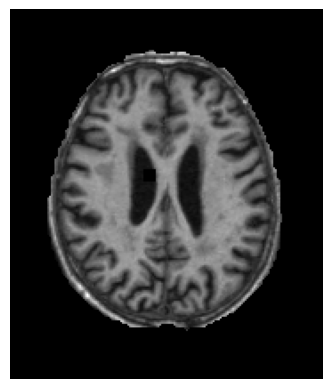

In [ ]:
w  = register(demo.iloc[0].hdr)
sl = np.rot90(w[:, :, 100])
sl = (sl - sl.min()) / (sl.max() + 1e-8) * 255

cerebro = sl[sl > 10]
print(f"p99 {np.percentile(cerebro,99):.0f} | mediana {np.median(cerebro):.0f}")
plt.imshow(sl, cmap="gray"); plt.axis("off"); plt.show()

p99 131 | mediana 75  (objetivo 228/146)


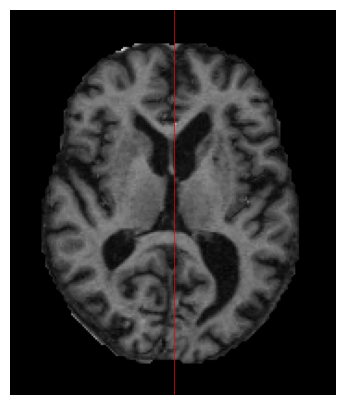

In [ ]:
w = register(demo.iloc[0].hdr)
s = np.rot90(w[:, :, 80])
s = (s - s.min()) / (s.max() + 1e-8) * 255
c = s[s > 10]
print(f"p99 {np.percentile(c,99):.0f} | mediana {np.median(c):.0f}  (objetivo 228/146)")

plt.figure(figsize=(5,5))
plt.imshow(s, cmap="gray"); plt.axvline(s.shape[1]//2, color='r', lw=0.5)
plt.axis("off"); plt.show()

In [ ]:
from scipy.ndimage import binary_fill_holes, binary_closing as bclose

def strip_mask(img_ants):
    """Máscara de cerebro reparada: quita cráneo pero no se come tejido interior."""
    prob = antspynet.brain_extraction(img_ants, modality="t1")
    m = ants.threshold_image(prob, 0.5, 1.0).numpy().astype(bool)
    m = bclose(m, np.ones((5, 5, 5)))    # cierra hendiduras del borde
    m = binary_fill_holes(m)             # recupera huecos interiores (el tálamo)
    return m

In [ ]:
from skimage.morphology import convex_hull_image

def strip_mask(img_ants):
    """Máscara convexa: recorta el exterior, imposible que muerda hacia dentro."""
    prob = antspynet.brain_extraction(img_ants, modality="t1")
    m = ants.threshold_image(prob, 0.5, 1.0).numpy().astype(bool)

    # envolvente convexa corte a corte (3D completo sería lentísimo)
    out = np.zeros_like(m)
    for k in range(m.shape[2]):
        if m[:, :, k].any():
            out[:, :, k] = convex_hull_image(m[:, :, k])
    return out


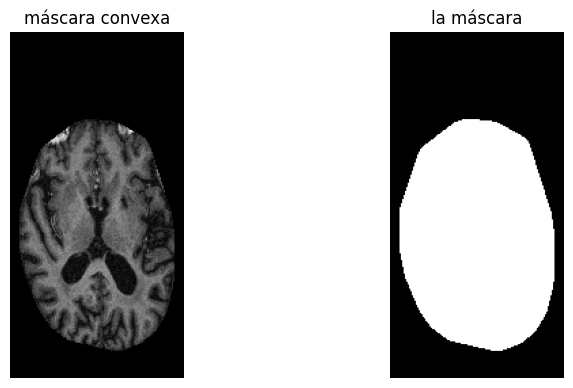

In [ ]:
m_fix = strip_mask(m0)
j = m0.shape[2] // 2

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(np.rot90(m0.numpy()[:, :, j] * m_fix[:, :, j]), cmap="gray")
ax[0].set_title("máscara convexa")
ax[1].imshow(np.rot90(m_fix[:, :, j].astype(float)), cmap="gray")
ax[1].set_title("la máscara")
for a in ax: a.axis("off")
plt.show()

In [ ]:
def register(hdr_path):
    nb = nib.load(str(hdr_path))
    xf = ornt_transform(io_orientation(nb.affine), axcodes2ornt(TARGET))
    nb = nb.as_reoriented(xf)

    arr = nb.get_fdata()
    if arr.ndim == 4:
        arr = arr[..., 0]

    spacing = tuple(float(z) for z in nb.header.get_zooms()[:3])
    original = ants.from_numpy(arr.astype(np.float32), spacing=spacing)

    m      = strip_mask(original)
    pelado = ants.from_numpy((arr * m).astype(np.float32), spacing=spacing)

    r1 = ants.registration(fixed=template_ants, moving=pelado, type_of_transform="Rigid")
    r2 = ants.registration(fixed=template_ants, moving=r1["warpedmovout"],
                           type_of_transform="Affine")

    return r2["warpedmovout"].numpy() * mask

p99 232 | mediana 138  (objetivo 228/146)


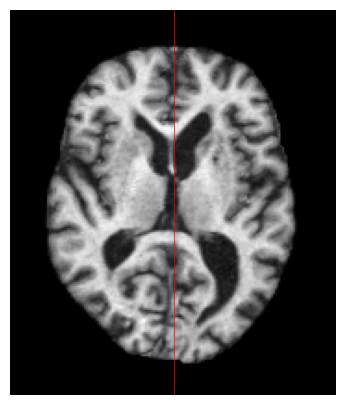

In [ ]:
w = register(demo.iloc[0].hdr)
s = np.rot90(w[:, :, 80])
s = (s - s.min()) / (s.max() + 1e-8) * 255
c = s[s > 10]
print(f"p99 {np.percentile(c,99):.0f} | mediana {np.median(c):.0f}  (objetivo 228/146)")

plt.figure(figsize=(5,5))
plt.imshow(s, cmap="gray"); plt.axvline(s.shape[1]//2, color='r', lw=0.5)
plt.axis("off"); plt.show()

In [ ]:
import shutil
shutil.rmtree(SL, ignore_errors=True)
(WORK / "manifest_external.csv").unlink(missing_ok=True)
print("limpio")

limpio


In [ ]:
objetivo = demo.sample(frac=1, random_state=42).reset_index(drop=True)
# objetivo = objetivo.head(70)     # si sale >120 s/vol

In [ ]:
objetivo = demo.sample(frac=1, random_state=42).reset_index(drop=True)
print(len(objetivo), objetivo.label.value_counts().to_dict())

134 {'non_demented': 71, 'alzheimer': 63}


In [ ]:
def register(hdr_path):
    nb = nib.load(str(hdr_path))
    xf = ornt_transform(io_orientation(nb.affine), axcodes2ornt(TARGET))
    nb = nb.as_reoriented(xf)

    arr = nb.get_fdata()
    if arr.ndim == 4:
        arr = arr[..., 0]

    spacing  = tuple(float(z) for z in nb.header.get_zooms()[:3])
    original = ants.from_numpy(arr.astype(np.float32), spacing=spacing)
    pelado   = strip(original)

    # las transformaciones se calculan con el cerebro pelado: converge mejor
    r1 = ants.registration(fixed=template_ants, moving=pelado,
                           type_of_transform="Rigid")
    r2 = ants.registration(fixed=template_ants, moving=r1["warpedmovout"],
                           type_of_transform="Affine")

    # pero se aplican a la ORIGINAL, con el tálamo intacto
    salida = ants.apply_transforms(
        fixed=template_ants, moving=original,
        transformlist=r2["fwdtransforms"] + r1["fwdtransforms"])

    return salida.numpy() * mask       # el cráneo lo quita la máscara geométrica

In [ ]:
r = demo.iloc[0]
print(r.mri_id, r.label, "CDR", r.CDR, "| nWBV", r.nWBV,
      "| media cohorte", demo.nWBV.mean().round(3))

OAS2_0001_MR1 non_demented CDR 0.0 | nWBV 0.696 | media cohorte 0.736


In [ ]:
r = demo.iloc[0]
print(r.mri_id, "|", r.label, "| CDR", r.CDR, "| nWBV", r.nWBV, "| edad", r.Age)
print("nWBV medio de la cohorte:", demo.nWBV.mean().round(3))

OAS2_0001_MR1 | non_demented | CDR 0.0 | nWBV 0.696 | edad 87
nWBV medio de la cohorte: 0.736


In [ ]:
from PIL import Image

o1_dir  = Path("/content/drive/MyDrive/AlzheimersProject/slices_2_classes")
o1_pngs = sorted(o1_dir.rglob("*.png"))
print(len(o1_pngs), "PNG |", o1_pngs[0].name if o1_pngs else "vacio")

1980 PNG | OAS1_0003_MR1_slice102.png


usando: OAS1_0003_MR1_slice80.png


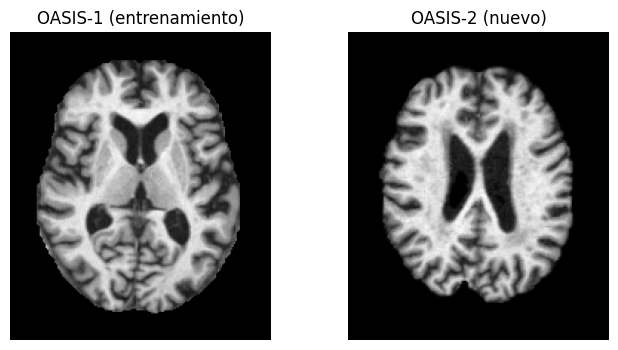

In [ ]:
un_paciente = sorted(o1_pngs[0].parent.glob("*.png"))
o1_png = un_paciente[len(un_paciente)//2]
print("usando:", o1_png.name)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(np.array(Image.open(o1_png)), cmap="gray"); ax[0].set_title("OASIS-1 (entrenamiento)")
ax[1].imshow(sl, cmap="gray");                            ax[1].set_title("OASIS-2 (nuevo)")
for a in ax: a.axis("off")
plt.show()

### CHECKPOINT 2 — go / no-go

Register a balanced handful and look at them before committing three hours.

muestra: {'non_demented': 3, 'alzheimer': 2}
.....
64 s/vol


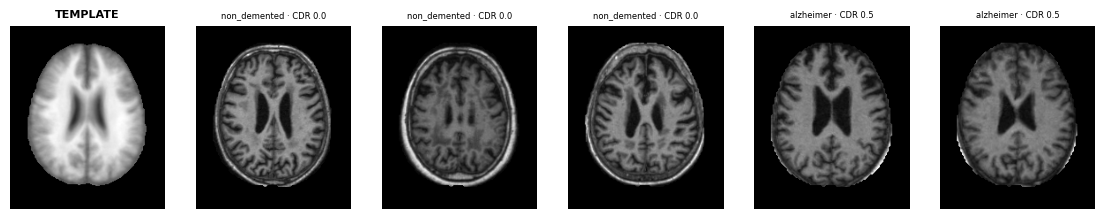

In [ ]:
prueba = demo.groupby("label").head(3).reset_index(drop=True).head(5)
print("muestra:", prueba.label.value_counts().to_dict())

regs = {}
t0 = time.time()
for row in prueba.itertuples(index=False):
    regs[row.mri_id] = register(row.hdr)
    print(".", end="", flush=True)
print(f"\n{(time.time()-t0)/len(prueba):.0f} s/vol")

fig, ax = plt.subplots(1, len(prueba)+1, figsize=(14, 3))
ax[0].imshow(np.rot90(template_data[:, :, 100]), cmap="gray")
ax[0].set_title("TEMPLATE", fontsize=8, weight="bold")
for k, row in enumerate(prueba.itertuples(index=False)):
    ax[k+1].imshow(np.rot90(regs[row.mri_id][:, :, 100]), cmap="gray")
    ax[k+1].set_title(f"{row.label} · CDR {row.CDR}", fontsize=6)
for a in ax: a.axis("off")
plt.show()

---
# 5. Slice extraction

`extract_slices` is **identical to the OASIS-1 version, unchanged**. That was the
entire point of registering: after resampling onto the template grid, `axis=2` and
`(80, 120)` mean the same thing they meant during training.

In [ ]:
slice_range = (80, 120)
num_slices  = 10
brain_view  = 2

def extract_slices(img_path, out_dir, subject_id,
                   slice_range=slice_range, n_slices=num_slices, axis=brain_view):
    img  = nib.load(img_path)
    data = img.get_fdata()

    if data.ndim == 4:
        data = data[..., 0]

    start, end = slice_range
    slice_indices = np.linspace(start, end, n_slices, dtype=int)

    out_dir.mkdir(parents=True, exist_ok=True)
    saved_paths = []

    for idx in slice_indices:
        sl = data[:, :, idx]
        sl = np.rot90(sl)

        sl = sl - sl.min()
        sl = sl / (sl.max() + 1e-8)
        sl = (sl * 255).astype(np.uint8)

        out_path = out_dir / f"{subject_id}_slice{idx}.png"
        Image.fromarray(sl).save(out_path)
        saved_paths.append(str(out_path))

    return saved_paths

---
# 6. Main loop

Registration and slicing happen in one pass. The registered volumes are **not**
kept: they would be ~3.4 GB on ephemeral disk, lost on disconnect. Only the PNGs
are written, straight to Drive, about 40 MB in total.

Resumable: patients that already have their 10 slices are skipped, so a
disconnection costs one patient rather than the whole run.

The order is **shuffled** so that an interrupted run leaves a random, balanced
subset rather than only the low-numbered IDs from PART1.

**Do not close the browser tab** — Colab disconnects sessions without an active
browser.

In [ ]:
TMP = Path("/content/tmp.nii.gz")
failed = []

pendientes = [r for r in objetivo.itertuples(index=False)
              if not (SL / r.label / r.mri_id).exists()
              or len(list((SL / r.label / r.mri_id).glob("*.png"))) != num_slices]

print(f"ya hechos: {len(objetivo) - len(pendientes)} | pendientes: {len(pendientes)}")

t0 = time.time()
for n, row in enumerate(pendientes, start=1):
    try:
        w = register(row.hdr)
        nib.save(nib.Nifti1Image(w.astype(np.float32), template_affine), TMP)
        extract_slices(img_path=TMP, out_dir=SL / row.label / row.mri_id,
                       subject_id=row.mri_id)
        estado = "ok"
    except Exception as e:
        failed.append((row.mri_id, str(e)[:80]))
        estado = "FALLO"

    t = (time.time() - t0) / 60
    print(f"[{n:>3}/{len(pendientes)}] {row.mri_id} {row.label:<13} {estado:<5} "
          f"| {t:.0f} min | faltan ~{t/n*(len(pendientes)-n):.0f} min", flush=True)

print("\nTERMINADO. fallos:", len(failed))
for f in failed[:10]:
    print(f)

ya hechos: 0 | pendientes: 134
[  1/134] OAS2_0165_MR1 alzheimer     ok    | 2 min | faltan ~201 min
[  2/134] OAS2_0171_MR1 non_demented  ok    | 3 min | faltan ~186 min
[  3/134] OAS2_0099_MR1 alzheimer     ok    | 4 min | faltan ~183 min
[  4/134] OAS2_0052_MR1 non_demented  ok    | 6 min | faltan ~182 min
[  5/134] OAS2_0100_MR1 non_demented  ok    | 7 min | faltan ~181 min
[  6/134] OAS2_0152_MR1 non_demented  ok    | 8 min | faltan ~181 min
[  7/134] OAS2_0035_MR1 non_demented  ok    | 10 min | faltan ~181 min
[  8/134] OAS2_0111_MR1 alzheimer     ok    | 11 min | faltan ~178 min
[  9/134] OAS2_0087_MR1 alzheimer     ok    | 13 min | faltan ~179 min
[ 10/134] OAS2_0088_MR1 alzheimer     ok    | 14 min | faltan ~175 min
[ 11/134] OAS2_0105_MR1 non_demented  ok    | 15 min | faltan ~173 min
[ 12/134] OAS2_0096_MR1 non_demented  ok    | 17 min | faltan ~173 min
[ 13/134] OAS2_0068_MR1 non_demented  ok    | 18 min | faltan ~171 min
[ 14/134] OAS2_0119_MR1 non_demented  ok    | 20 min

---
# 7. Manifest

Rebuilt by reading the folders rather than from the loop's return values, so it
survives an interrupted run.

In [ ]:
from collections import Counter
pngs = list(SL.rglob("*.png"))
c = Counter(p.parent.name for p in pngs)
completos = [k for k, v in c.items() if v == num_slices]

print("pacientes completos:", len(completos))
print("incompletos:", [k for k, v in c.items() if v != num_slices])
print(demo[demo.mri_id.isin(completos)].label.value_counts().to_dict())
print("CDR:", demo[demo.mri_id.isin(completos)].CDR.value_counts().sort_index().to_dict())

NameError: name 'SL' is not defined

In [ ]:
rows = []
for row in objetivo.itertuples(index=False):
    for p in sorted((SL / row.label / row.mri_id).glob("*.png")):
        rows.append({"subject_id": row.mri_id,
                     "label":      row.label,
                     "cdr":        row.CDR,
                     "image_path": str(p),
                     "label_id":   row.label_id})

ext = pd.DataFrame(rows)
ext.to_csv(WORK / "manifest_external.csv", index=False)

print(ext.subject_id.nunique(), "pacientes,", len(ext), "imagenes")
print(ext.groupby("label").subject_id.nunique().to_dict())

In [ ]:
muestra = ext.groupby("subject_id").first().sample(8, random_state=0)

fig, ax = plt.subplots(1, 8, figsize=(18, 3))
for k, (sid, r) in enumerate(muestra.iterrows()):
    ax[k].imshow(Image.open(r.image_path), cmap="gray")
    ax[k].set_title(f"{r.label}\nCDR {r.cdr}", fontsize=7)
    ax[k].axis("off")
plt.show()